# Rasterization

Conversion from vector or matrix to raster

## Settings

In [1]:
# Load packages
suppressPackageStartupMessages({
  library(terra)
})

# Parameters
param_field <- "NAME_2"
param_function <- "sum"
param_background <- NA
param_touches <- FALSE
param_mode <- "binary"
param_group <- NULL
param_out <- tempdir()
param_overwrite <- TRUE

# Paths for examples
in_raster <- system.file("ex/elev.tif", package = "terra")
in_vector <- system.file("ex/lux.shp", package = "terra")

## Rasterize vector data

Transfer values associated with the geometries of vector data to a raster

In [2]:
# GSTB rasterize vector
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - in_vector: String
#    - in_raster: String
#   params:
#    - param_field: String
#    - param_mode: String
#    - param_fun: String
#    - param_touches: Boolean
#    - param_group: String
#    - param_background: String
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# SpatVector to be rasterized
x <- vect(in_vector)

# SpatRaster to define spatial characteristics
if(!is.null(in_raster)) {
  y <- rast(in_raster)
} else {
  y <- rast(x, ncols = 100, nrows = 100)
}

# Rasterize
#   mode = "binary" : returns whether a cell is covered by the polygons
#   mode = "fraction" : returns the fraction of a cell that is covered by the polygons
if(param_mode == "binary") {
  rasterize(x          = x,
            y          = y,
            field      = param_field,
            fun        = param_function,
            background = param_background,
            touches    = param_touches,
            update     = FALSE,
            cover      = FALSE,
            by         = param_group,
            filename   = paste0(param_out, "/rasterized_vector.tif"),
            overwrite  = TRUE)
} else if(param_mode == "fraction") {
  rasterize(x          = x,
            y          = y,
            field      = param_field,
            fun        = param_fun,
            background = param_background,
            touches    = param_touches,
            update     = FALSE,
            cover      = TRUE,
            by         = param_group,
            filename   = paste0(param_out, "/rasterized_vector.tif"),
            overwrite  = TRUE)
}

# Output
out <- list.files(path = param_out,
                  pattern = "rasterized_vector.tif",
                  full.names = TRUE)

class       : SpatRaster 
dimensions  : 90, 95, 1  (nrow, ncol, nlyr)
resolution  : 0.008333333, 0.008333333  (x, y)
extent      : 5.741667, 6.533333, 49.44167, 50.19167  (xmin, xmax, ymin, ymax)
coord. ref. : lon/lat WGS 84 (EPSG:4326) 
source      : rasterized_vector.tif 
varname     : elev 
name        : NAME_2 
min value   :      0 
max value   :     11 

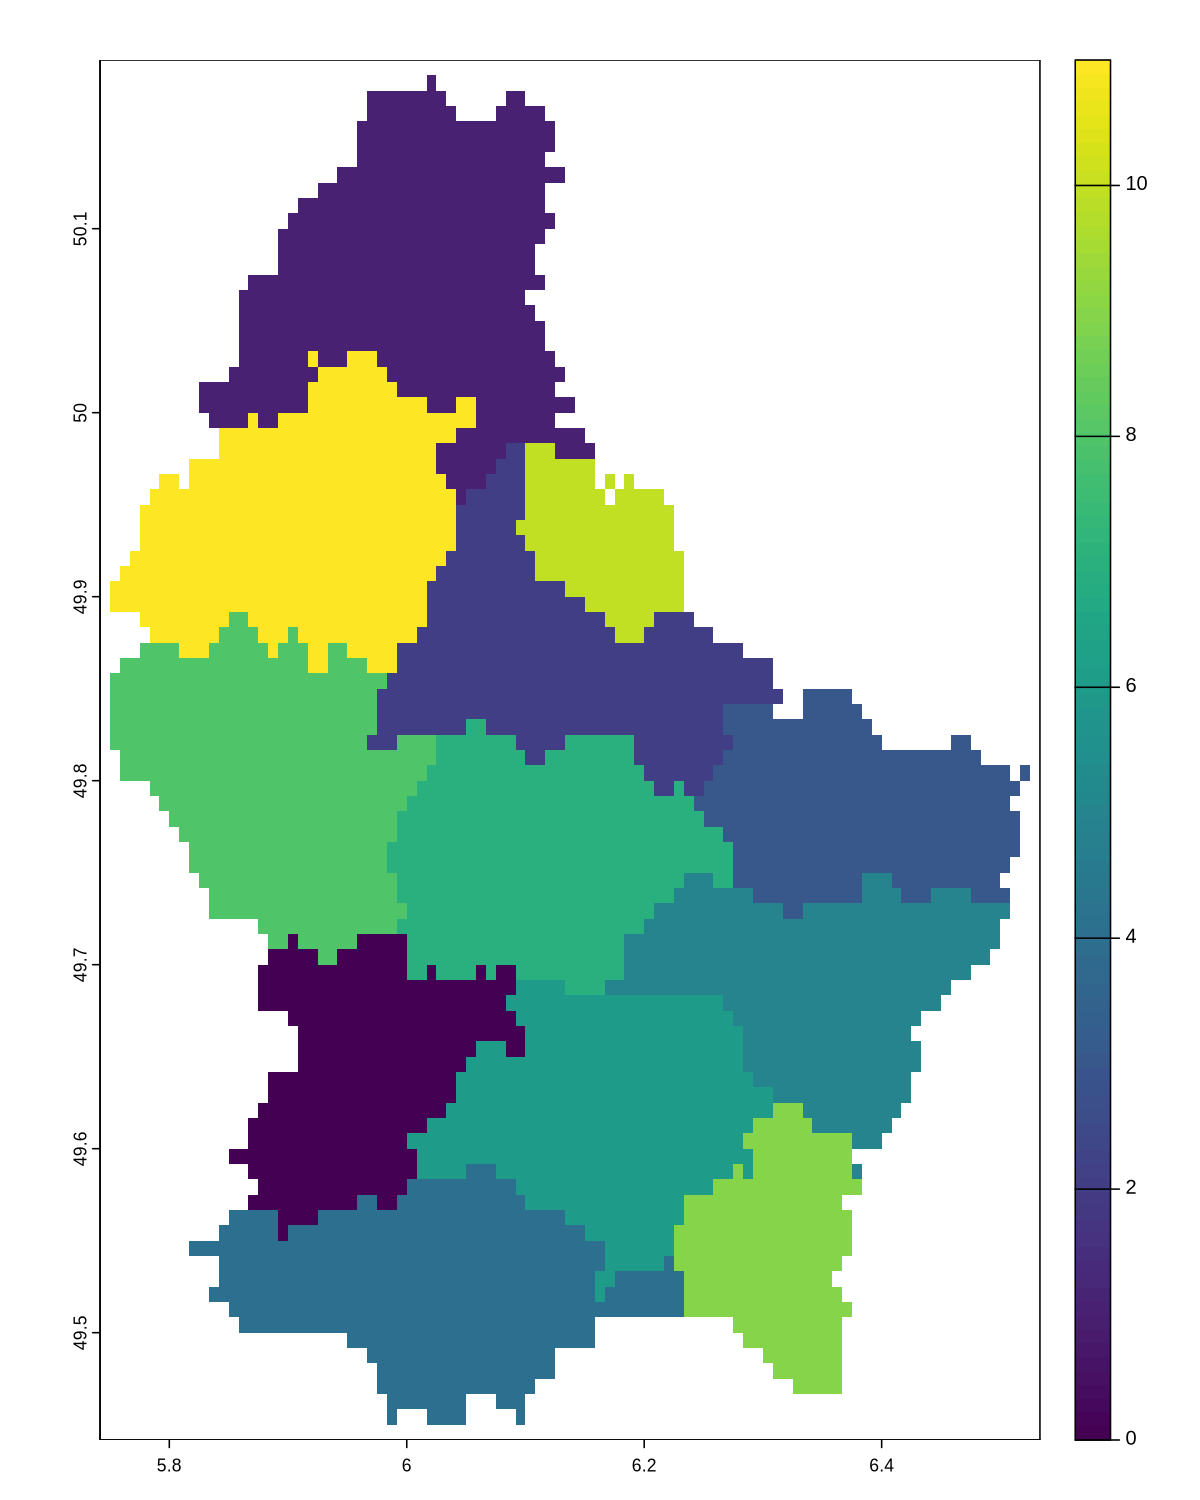

In [4]:
options(repr.plot.width = 8,
        repr.plot.height = 10,
        repr.plot.res = 150)
plot(rast(out))

## Rasterize matrix data

Transfer values associated with matrix data to a raster

In [6]:
# GSTB rasterize matrix
# NaaVRE:
#  cell:
#   inputs:
#    - in_matrix: String
#    - in_raster: String
#   params:
#    - param_values: List
#    - param_function: String
#    - param_background: String
#    - param_group: String
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# Two-column matrix (point coordinates) or data.frame to be rasterized
x <- read.csv(in_matrix)
 
# SpatRaster to define spatial characteristics
if(!is.null(in_raster)) {
  y <- rast(in_raster)
}

# Rasterize
rasterize(x          = x,
          y          = y,
          values     = param_values,
          fun        = param_function,
          background = param_background,
          update     = FALSE,
          by         = param_group,
          filename   = paste0(param_out, "/rasterized_matrix.tif"),
          overwrite  = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "rasterized_matrix.tif",
                  full.names = TRUE)

ERROR: Error: object 'in_matrix' not found
